# Predicción binaria con un conjunto de datos de precipitaciones
Iniciamos importando las bibliotecas necesarias

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

%matplotlib inline

Cargamos los datos y generamos los dataframes

In [288]:
train_data = pd.read_csv("C:\\Users\\rodri\\OneDrive\\Desktop\\Ciencia de datos y ML\\Aprendizaje automatico (Kaggle)\\Proyecto 2\\train.csv")
test_data = pd.read_csv("C:\\Users\\rodri\\OneDrive\\Desktop\\Ciencia de datos y ML\\Aprendizaje automatico (Kaggle)\\Proyecto 2\\test.csv")

Inspeccionamos y ajustamos las características

In [289]:
train_data['rainfall'].value_counts()
correlation_values = abs(train_data.corr()['rainfall'].drop('rainfall')).sort_values(ascending=False)
print("Correlaciones con 'rainfall':\n", correlation_values)

Correlaciones con 'rainfall':
 cloud            0.641191
sunshine         0.555287
humidity         0.454213
windspeed        0.111625
dewpoint         0.081965
maxtemp          0.079304
pressure         0.049886
temparature      0.049660
id               0.033674
mintemp          0.026841
winddirection    0.006939
day              0.000462
Name: rainfall, dtype: float64


Dividimos las características y las etiquetas

In [290]:
X = train_data.drop(columns=["rainfall"])
y = train_data["rainfall"]

Dividimos en conjuntos de entrenamiento y validación

In [291]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Escalamos las características

In [292]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Modelo de clasificación KNN

Buscamos el hiperparámetro con el valor óptimo

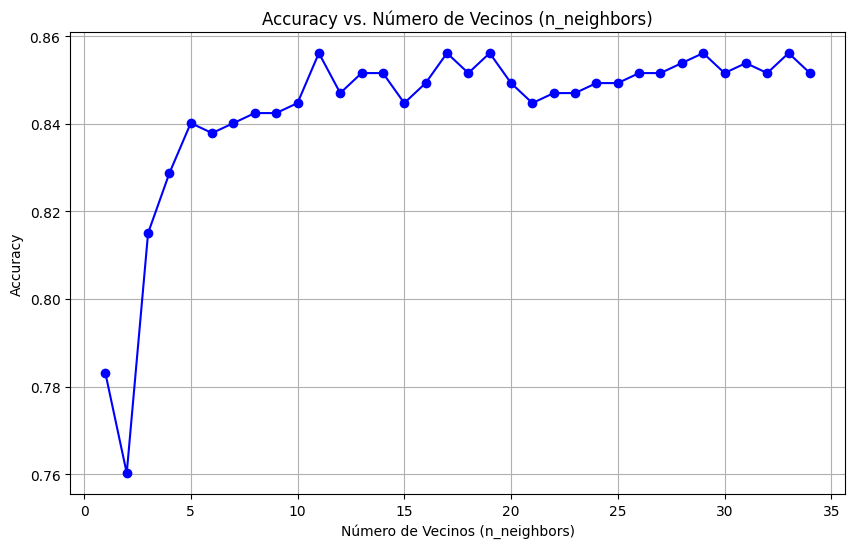

In [293]:
n_neighbors_range = range(1, 35)
accuracies = []

for n in n_neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(n_neighbors_range, accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Número de Vecinos (n_neighbors)')
plt.xlabel('Número de Vecinos (n_neighbors)')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

In [294]:
knn = KNeighborsClassifier(n_neighbors=11)

# Entrenamos el modelo
knn.fit(X_train_scaled, y_train)

# Predecir en el conjunto de validación
y_pred = knn.predict(X_val_scaled)

# Evaluar el modelo
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.8561643835616438
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.61      0.70       119
           1       0.87      0.95      0.91       319

    accuracy                           0.86       438
   macro avg       0.84      0.78      0.80       438
weighted avg       0.85      0.86      0.85       438



In [295]:
from sklearn.impute import SimpleImputer

# Manejar valores faltantes en test_data
imputer = SimpleImputer(strategy='mean')  # Imputador usando la media
X_test = test_data.drop(columns=["rainfall"], errors="ignore")  # Asegúrate de no incluir la columna objetivo
X_test = imputer.fit_transform(X_test)  # Rellenar valores faltantes

# Escalar los datos
X_test_scaled = scaler.transform(X_test)

# Realizar predicciones
y_pred = knn.predict(X_test_scaled)

# Crear un DataFrame con ID y predicciones
output = pd.DataFrame({
    'id': test_data['id'],  # Asegúrate de que test_data tenga una columna 'id'
    'rainfall': y_pred
})

# Guardar el archivo en formato CSV
output.to_csv("submission.csv", index=False)

print("El archivo 'submission.csv' se generó correctamente.")


El archivo 'submission.csv' se generó correctamente.
